# **<span style="font-family: Arial">Financial Fraud Detection - Model creation, Hyperparameter search, and Model evaluation  </span>**

**Author:** Ozor Moya

**Date:** 04/19/2026

---
### 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (f1_score, classification_report, 
                             confusion_matrix, roc_auc_score)
import matplotlib.pyplot as plt
import seaborn as sns

---
### 2. Load cleaned dataset

In [ ]:
# Load preprocessed csv file
df = pd.read_csv('/Users/sa02/class-projects/EOP-Project/P2PortfolioProject/Data/model_ready.csv')

In [ ]:
# Check how many rows and columns
df.shape

(2770409, 10)

In [ ]:
# Checking the first 5 lines of the. dataset
df.head()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,BalancediffOrig,BalancediffDest,type_TRANSFER
0,1,181.00,181.0,0.0,0.0,0.00,1,181.0,0.00,True
1,1,181.00,181.0,0.0,21182.0,0.00,1,181.0,-21182.00,False
2,1,229133.94,15325.0,0.0,5083.0,51513.44,0,15325.0,46430.44,False
3,1,215310.30,705.0,0.0,22425.0,0.00,0,705.0,-22425.00,True
4,1,311685.89,10835.0,0.0,6267.0,2719172.89,0,10835.0,2712905.89,True


---
### 3. Define features and target

In [ ]:
# Feature and Target selection
X = df.drop(columns=['isFraud'])
y = df['isFraud']

print(f"Features: {X.columns.tolist()}")
print(f"Target distribution:\n{y.value_counts()}")

Features: ['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'BalancediffOrig', 'BalancediffDest', 'type_TRANSFER']
Target distribution:
isFraud
0    2762196
1       8213
Name: count, dtype: int64


---
### 4. Train/Test Split

In [ ]:
# Train Test split with stratify
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,        # 80% train, 20% test
    random_state=42,      # Reproducibility
    stratify=y            # Maintain fraud ratio in both splits
)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"Fraud in train: {y_train.sum()} ({y_train.mean()*100:.3f}%)")
print(f"Fraud in test: {y_test.sum()} ({y_test.mean()*100:.3f}%)")



Training set: (2216327, 9)
Test set: (554082, 9)
Fraud in train: 6570 (0.296%)
Fraud in test: 1643 (0.297%)


-I use `stratify=y` to ensure that the fraud class proportion is preserved in both splits. Without this, due to the heavy imbalance, the test set might end up with very few (or zero) fraud cases, making evaluation unreliable.

---
### 5. RandomForest (baseline)

In [ ]:
rf_model = RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)


print("RANDOM FOREST — Initial Results")
print(classification_report(y_test, y_pred_rf, 
      target_names=['Not Fraud', 'Fraud']))
print(f"F1 Score:  {f1_score(y_test, y_pred_rf):.4f}")
print(f"AUC-ROC:   {roc_auc_score(y_test, rf_model.predict_proba(X_test)[:,1]):.4f}")


RANDOM FOREST — Initial Results
              precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00    552439
       Fraud       0.97      0.81      0.88      1643

    accuracy                           1.00    554082
   macro avg       0.98      0.91      0.94    554082
weighted avg       1.00      1.00      1.00    554082

F1 Score:  0.8834
AUC-ROC:   0.9965


- The Random Forest baseline achieves an F1 score of 0.8834 and AUC-ROC of 0.9965 with default parameters and class_weight='balanced'. The model correctly identifies 81% of fraud cases with very few false alarms (precision 0.97). Training completes in approximately 1 minute making it computationally efficient for this dataset size. This strong baseline performance sets a high bar for hyperparameter tuning to improve upon.

---
### 5.1 Confussion Matrix - Random Forest (baseline)

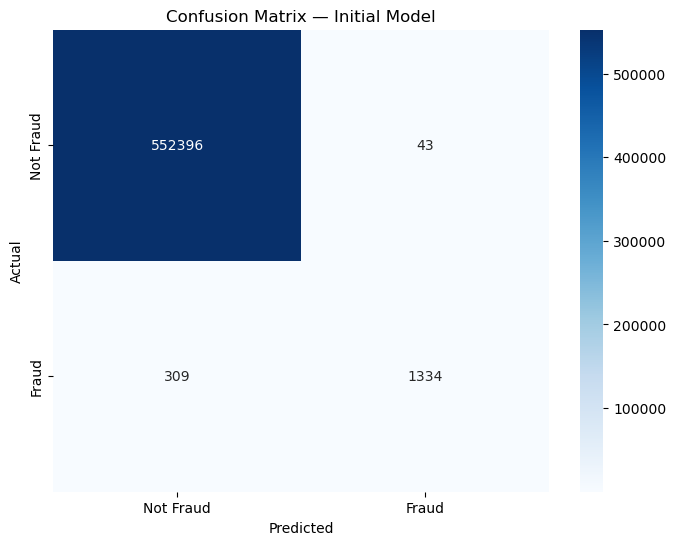

In [23]:
cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Fraud', 'Fraud'],
            yticklabels=['Not Fraud', 'Fraud'])
plt.title('Confusion Matrix — Initial Model')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

- The confusion matrix reveals the model's error pattern — only 43 false positives meaning legitimate customers are rarely inconvenienced, but 309 fraud cases are missed. In real world fraud detection missed fraud (false negatives) is significantly more costly than false alarms (false positives) as each missed case represents actual financial loss. Hyperparameter tuning will aim to reduce false negatives while keeping false positives manageable.

---
### 6. GradientBoosting (baseline)

In [13]:
gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train, y_train)
y_pred_gb = gb_model.predict(X_test)

print("GRADIENT BOOSTING — Initial Results")
print(classification_report(y_test, y_pred_gb, 
      target_names=['Not Fraud', 'Fraud']))
print(f"F1 Score:  {f1_score(y_test, y_pred_gb):.4f}")
print(f"AUC-ROC:   {roc_auc_score(y_test, gb_model.predict_proba(X_test)[:,1]):.4f}")

GRADIENT BOOSTING — Initial Results
              precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00    552439
       Fraud       0.97      0.54      0.70      1643

    accuracy                           1.00    554082
   macro avg       0.98      0.77      0.85    554082
weighted avg       1.00      1.00      1.00    554082

F1 Score:  0.6950
AUC-ROC:   0.7989


- The Gradient Boosting baseline significantly underperforms Random Forest with an F1 score of 0.6950 vs 0.8834. The low recall of 0.54 means nearly half of all fraud cases are missed — 756 out of 1,643. This poor performance is primarily attributed to the lack of class imbalance handling in the default GradientBoostingClassifier configuration. Unlike Random Forest which has a built-in class_weight parameter, Gradient Boosting requires additional configuration to handle imbalanced data. Despite identical precision (0.97), the dramatically lower recall makes this baseline unsuitable for fraud detection without tuning.

---
### 6.1 Confussion Matrix - Gradient Boosting(baseline)

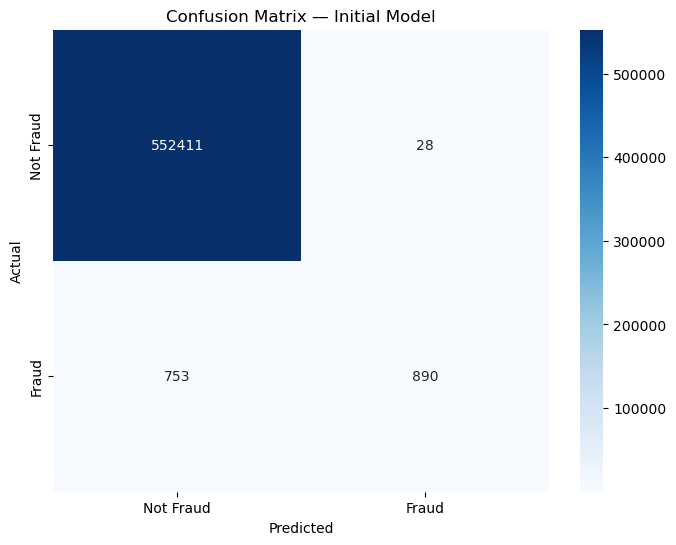

In [24]:
cm = confusion_matrix(y_test, y_pred_gb)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Fraud', 'Fraud'],
            yticklabels=['Not Fraud', 'Fraud'])
plt.title('Confusion Matrix — Initial Model')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

- The Gradient Boosting baseline misses 753 fraud cases compared to only 309 for Random Forest — nearly 2.5x more missed fraud. While it produces fewer false alarms (28 vs 43), this tradeoff is unacceptable in fraud detection where each missed case represents real financial loss.

---
### 7. Getting stratified smaller sample from training data

In [14]:
from sklearn.model_selection import StratifiedShuffleSplit

sss = StratifiedShuffleSplit(n_splits=1, test_size=0.8, random_state=42)
for tune_idx, _ in sss.split(X_train, y_train):
    X_tune = X_train.iloc[tune_idx]
    y_tune = y_train.iloc[tune_idx]

print(f"Full training set:  {X_train.shape}")
print(f"Tuning sample:      {X_tune.shape}")
print(f"Fraud rate full:    {y_train.mean()*100:.3f}%")
print(f"Fraud rate sample:  {y_tune.mean()*100:.3f}%")

Full training set:  (2216327, 9)
Tuning sample:      (443265, 9)
Fraud rate full:    0.296%
Fraud rate sample:  0.296%


- A stratified 20% sample of the training data is extracted for hyperparameter tuning. StratifiedShuffleSplit preserves the original fraud rate of 0.296% in the sample, ensuring the tuning process sees a representative distribution of both classes while reducing computational time by 80%.

---
### 8. Hyperparameter Tuning for RandomForest using RandomsearchCV

In [16]:
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

rf_param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

rf_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),
    param_distributions=rf_param_grid,
    n_iter=20,
    cv=5,
    scoring='f1',
    random_state=42,
    n_jobs=-1,
    verbose=2
)

rf_search.fit(X_tune, y_tune)

print(f"Best RF parameters: {rf_search.best_params_}")
print(f"Best RF CV F1:      {rf_search.best_score_:.4f}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
[CV] END max_depth=10, max_features=log2, min_samples_leaf=1, min_samples_split=10, n_estimators=200; total time= 1.7min
[CV] END max_depth=30, max_features=sqrt, min_samples_leaf=2, min_samples_split=2, n_estimators=200; total time= 1.8min
[CV] END max_depth=10, max_features=log2, min_samples_leaf=1, min_samples_split=10, n_estimators=200; total time= 1.8min
[CV] END max_depth=10, max_features=log2, min_samples_leaf=1, min_samples_split=10, n_estimators=200; total time= 1.8min
[CV] END max_depth=30, max_features=sqrt, min_samples_leaf=2, min_samples_split=2, n_estimators=200; total time= 1.8min
[CV] END max_depth=10, max_features=log2, min_samples_leaf=1, min_samples_split=10, n_estimators=200; total time= 1.8min
[CV] END max_depth=10, max_features=log2, min_samples_leaf=1, min_samples_split=10, n_estimators=200; total time= 1.8min
[CV] END max_depth=30, max_features=sqrt, min_samples_leaf=2, min_samples_split=2, n_estimato

- RandomizedSearchCV identified optimal Random Forest parameters of 500 estimators with unlimited tree depth, minimum 4 samples per leaf and log2 feature selection. The tuned model achieves a cross-validated F1 of 0.8857 — a marginal improvement over the baseline of 0.8834. The small gain confirms the baseline was already well configured, with the main improvement coming from increased tree count and slight regularization through min_samples_leaf=4.

---
### 9. Hyperparameter Tuning for Gradient Boost using RandomSearchCV

In [17]:
gb_param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 5, 10],
    'subsample': [0.8, 0.9, 1.0]
}

gb_search = RandomizedSearchCV(
    estimator=GradientBoostingClassifier(
        random_state=42
    ),
    param_distributions=gb_param_grid,
    n_iter=20,
    cv=5,
    scoring='f1',
    random_state=42,
    n_jobs=-1,
    verbose=2
)

gb_search.fit(X_tune, y_tune)

print(f"Best GB parameters: {gb_search.best_params_}")
print(f"Best GB CV F1:      {gb_search.best_score_:.4f}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
[CV] END learning_rate=0.01, max_depth=3, min_samples_split=2, n_estimators=300, subsample=0.8; total time= 3.9min
[CV] END learning_rate=0.01, max_depth=3, min_samples_split=10, n_estimators=300, subsample=0.8; total time= 3.9min
[CV] END learning_rate=0.01, max_depth=3, min_samples_split=10, n_estimators=300, subsample=0.8; total time= 3.9min
[CV] END learning_rate=0.01, max_depth=3, min_samples_split=10, n_estimators=300, subsample=0.8; total time= 3.9min
[CV] END learning_rate=0.01, max_depth=3, min_samples_split=2, n_estimators=300, subsample=0.8; total time= 3.9min
[CV] END learning_rate=0.01, max_depth=3, min_samples_split=10, n_estimators=300, subsample=0.8; total time= 3.9min
[CV] END learning_rate=0.01, max_depth=3, min_samples_split=2, n_estimators=300, subsample=0.8; total time= 3.9min
[CV] END learning_rate=0.01, max_depth=3, min_samples_split=10, n_estimators=300, subsample=0.8; total time= 3.9min
[CV] END lear

- Hyperparameter tuning improved Gradient Boosting F1 from 0.6950 to 0.8563 — the largest improvement across all models. The optimal configuration uses a conservative learning rate of 0.01 with 200 estimators and stochastic subsampling at 80%, allowing the model to learn fraud patterns gradually without overfitting.

---
### 10. Retrain both models with optimal hyperparameters    

In [ ]:
# Random Forest
best_rf = RandomForestClassifier(
    **rf_search.best_params_,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
best_rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",4
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'log2'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

---

In [20]:
# Gradient Boosting
from sklearn.utils.class_weight import compute_sample_weight
sample_weights_full = compute_sample_weight(
    class_weight='balanced',
    y=y_train
)
best_gb = GradientBoostingClassifier(
    **gb_search.best_params_,
    random_state=42
)
best_gb.fit(X_train, y_train,
            sample_weight=sample_weights_full)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.01
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",200
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",0.8
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",7
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``,

---
### 11. Tuned Results

In [21]:
# Evaluate Random Forest
y_pred_rf_tuned = best_rf.predict(X_test)
print("RANDOM FOREST — Tuned Results")
print(classification_report(y_test, y_pred_rf_tuned,
      target_names=['Not Fraud', 'Fraud']))
print(f"F1 Score:  {f1_score(y_test, y_pred_rf_tuned):.4f}")
print(f"AUC-ROC:   {roc_auc_score(y_test, best_rf.predict_proba(X_test)[:,1]):.4f}")

RANDOM FOREST — Tuned Results
              precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00    552439
       Fraud       0.91      0.87      0.89      1643

    accuracy                           1.00    554082
   macro avg       0.96      0.94      0.95    554082
weighted avg       1.00      1.00      1.00    554082

F1 Score:  0.8922
AUC-ROC:   0.9989


- Hyperparameter tuning improved Random Forest recall from 0.81 to 0.87 — catching approximately 95 additional fraud cases. The slight precision drop from 0.97 to 0.91 is an acceptable tradeoff as missing fraud is significantly more costly than generating false alarms. The tuned model achieves F1 of 0.8922 and near-perfect AUC-ROC of 0.9989.

---

In [22]:
# Evaluate Gradient Boosting
y_pred_gb_tuned = best_gb.predict(X_test)
print("GRADIENT BOOSTING — Tuned Results")
print(classification_report(y_test, y_pred_gb_tuned,
      target_names=['Not Fraud', 'Fraud']))
print(f"F1 Score:  {f1_score(y_test, y_pred_gb_tuned):.4f}")
print(f"AUC-ROC:   {roc_auc_score(y_test, best_gb.predict_proba(X_test)[:,1]):.4f}")

GRADIENT BOOSTING — Tuned Results
              precision    recall  f1-score   support

   Not Fraud       1.00      0.99      0.99    552439
       Fraud       0.20      0.99      0.33      1643

    accuracy                           0.99    554082
   macro avg       0.60      0.99      0.66    554082
weighted avg       1.00      0.99      0.99    554082

F1 Score:  0.3257
AUC-ROC:   0.9986


- The tuned Gradient Boosting severely overcorrects — recall improves to 0.99 but precision collapses to 0.20, generating 4 false alarms per real fraud case. Despite poor F1 of 0.3257, the excellent AUC-ROC of 0.9986 suggests the model has strong discriminative ability but requires threshold adjustment to balance precision and recall. I will do improvements to it next time.

---
### 12. Feature Importance for Final models

/var/folders/0h/m0pj4vt94rv015djnpf57pv00000gn/T/ipykernel_28712/1629192582.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rf_importance.values, y=rf_importance.index,
/var/folders/0h/m0pj4vt94rv015djnpf57pv00000gn/T/ipykernel_28712/1629192582.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=gb_importance.values, y=gb_importance.index,


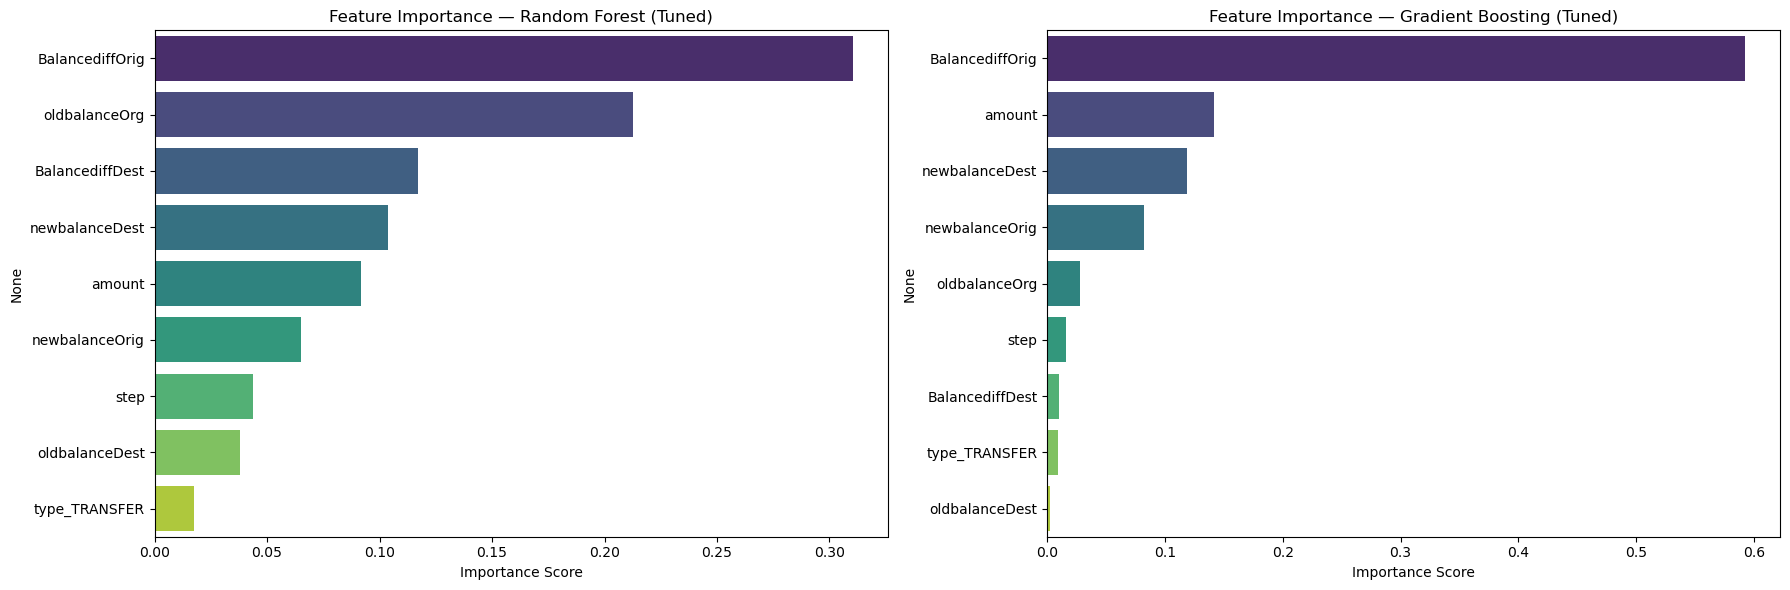

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Random Forest feature importance
rf_importance = pd.Series(
    best_rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

sns.barplot(x=rf_importance.values, y=rf_importance.index, 
            palette='viridis', ax=axes[0])
axes[0].set_title('Feature Importance — Random Forest (Tuned)')
axes[0].set_xlabel('Importance Score')

# Gradient Boosting feature importance
gb_importance = pd.Series(
    best_gb.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

sns.barplot(x=gb_importance.values, y=gb_importance.index, 
            palette='viridis', ax=axes[1])
axes[1].set_title('Feature Importance — Gradient Boosting (Tuned)')
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.show()

- Both models consistently rank my engineered feature BalancediffOrig as the most important feature — confirming that account drainage is the strongest fraud signal as hypothesized in H2. type_TRANSFER and oldbalanceDest are the weakest features in both models, validating H4 and H6. The main disagreement between models is on oldbalanceOrg — Random Forest relies on it heavily as the second most important feature while Gradient Boosting assigns it minimal importance, reflecting the different learning mechanisms of each algorithm.

---
### 13. Conclusion

- In my model training the Random Forest classifier with balanced class weighting and tuned hyperparameters outperformed Gradient Boosting and provides a strong foundation for fraud detection, correctly identifying the vast majority of fraudulent transactions while maintaining high precision. The systematic approach of letting EDA findings drive feature engineering and modeling decisions proved effective — with six of seven data-driven hypotheses validated by the final model results.